In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  

Data preprocessing

Training image preprocessing

In [11]:
 training_set = tf.keras.utils.image_dataset_from_directory("/kaggle/input/plant-disease-detection/Plant_Disease_Dataset/Plant_Disease_Dataset/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,                                                        
)

Found 70295 files belonging to 38 classes.


I0000 00:00:1762457093.800931      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
validation_set = tf.keras.utils.image_dataset_from_directory("/kaggle/input/plant-disease-detection/Plant_Disease_Dataset/Plant_Disease_Dataset/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [32]:
training_set


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [33]:
for x,y in training_set:
    print(x, x.shape)
    print(y, y.shape)
    break

tf.Tensor(
[[[[174.5  165.5  170.5 ]
   [190.   181.   186.  ]
   [184.75 175.75 180.75]
   ...
   [176.   167.   170.  ]
   [165.25 156.25 159.25]
   [175.25 166.25 169.25]]

  [[168.   159.   164.  ]
   [171.   162.   167.  ]
   [160.25 151.25 156.25]
   ...
   [167.5  158.5  161.5 ]
   [175.75 166.75 169.75]
   [177.25 168.25 171.25]]

  [[158.5  149.5  154.5 ]
   [170.   161.   166.  ]
   [176.75 167.75 172.75]
   ...
   [175.25 166.25 169.25]
   [181.5  172.5  175.5 ]
   [180.   171.   174.  ]]

  ...

  [[123.75 111.75 115.75]
   [124.5  112.5  116.5 ]
   [126.75 114.75 118.75]
   ...
   [137.5  125.5  125.5 ]
   [140.   128.   128.  ]
   [149.75 137.75 137.75]]

  [[133.75 121.75 125.75]
   [124.5  112.5  116.5 ]
   [132.25 120.25 124.25]
   ...
   [152.   140.   140.  ]
   [145.5  133.5  133.5 ]
   [133.75 121.75 121.75]]

  [[137.5  125.5  129.5 ]
   [130.75 118.75 122.75]
   [133.25 121.25 125.25]
   ...
   [131.   119.   119.  ]
   [133.5  121.5  121.5 ]
   [140.25 128.25 12

In [34]:
#building model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))


model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Flatten())
model.add(Dense(units=1024,activation='relu'))

#output layer
model.add(Dense(units=38, activation = 'softmax'))

In [35]:
#compiling model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989,446 (68.62 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#model training
training_history = model.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 148s 63ms/step - accuracy: 0.3250 - loss: 2.7935 - val_accuracy: 0.8422 - val_loss: 0.4967
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.8537 - loss: 0.4559 - val_accuracy: 0.8935 - val_loss: 0.3244
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9093 - loss: 0.2779 - val_accuracy: 0.8730 - val_loss: 0.4154
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9236 - loss: 0.2257 - val_accuracy: 0.8976 - val_loss: 0.3311
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9438 - loss: 0.1704 - val_accuracy: 0.8977 - val_loss: 0.3845
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9508 - loss: 0.1481 - val_accuracy: 0.9058 - val_loss: 0.3342
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9533 - loss: 0.1427 - val_accuracy: 0.8758 - val_loss: 0.4896
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 61s 28ms/step - accuracy: 0.9577 

In [37]:
#Model evaluation on training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9540 - loss: 0.1586


In [38]:
print(train_loss,train_acc)

0.13784070312976837 0.9597695469856262


In [39]:
#Model evaluation on validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9027 - loss: 0.3923


In [40]:
print(val_loss,val_acc)

0.40383416414260864 0.9019463062286377


In [41]:
model.save("/kaggle/working/trained_disease.keras")

In [42]:
import os
os.listdir("/kaggle/working")


['.virtual_documents', 'trained_disease.keras']

In [43]:
training_history.history

{'accuracy': [0.5656021237373352,
  0.8738886117935181,
  0.9157977104187012,
  0.9289707541465759,
  0.9454726576805115,
  0.9513763189315796,
  0.9547478556632996,
  0.9586741328239441,
  0.9596841931343079,
  0.9619460701942444],
 'loss': [1.5498377084732056,
  0.389105886220932,
  0.255392849445343,
  0.21220535039901733,
  0.16689811646938324,
  0.14703544974327087,
  0.1380239576101303,
  0.1303877979516983,
  0.12764959037303925,
  0.1210220530629158],
 'val_accuracy': [0.8422490358352661,
  0.8935238122940063,
  0.8730366230010986,
  0.897621214389801,
  0.8976781368255615,
  0.9058160781860352,
  0.87576824426651,
  0.9092875123023987,
  0.9152060151100159,
  0.9019463062286377],
 'val_loss': [0.49674537777900696,
  0.324389785528183,
  0.415396124124527,
  0.33106401562690735,
  0.38453587889671326,
  0.3341684341430664,
  0.4896177649497986,
  0.33132123947143555,
  0.3188419044017792,
  0.4038342237472534]}

In [44]:
#recording history in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)
    

## Accuracy visualization

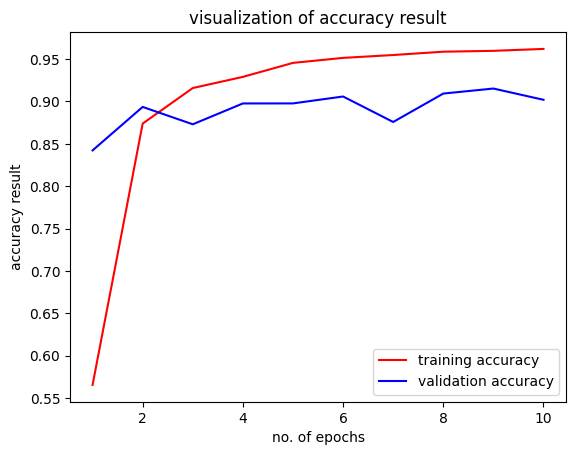

In [45]:
epochs = [i for i in range(1,11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='training accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='validation accuracy')
plt.xlabel("no. of epochs")
plt.ylabel("accuracy result")
plt.title("visualization of accuracy result")
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [46]:
class_name = validation_set.class_names
class_name

['Apple_Apple_scab',
 'Apple_Black_rot',
 'Apple_Cedar_apple_rust',
 'Apple_healthy',
 'Blueberry_healthy',
 'Cherry_including_sour_Powdery_mildew',
 'Cherry_including_sour_healthy',
 'Corn_maize_Cercospora_leaf_spot_Gray_leaf_spot',
 'Corn_maize_Common_rust_',
 'Corn_maize_Northern_Leaf_Blight',
 'Corn_maize_healthy',
 'Grape_Black_rot',
 'Grape_Esca_Black_Measles',
 'Grape_Leaf_blight_Isariopsis_Leaf_Spot',
 'Grape_healthy',
 'Orange_Haunglongbing_Citrus_greening',
 'Peach_Bacterial_spot',
 'Peach_healthy',
 'Pepper_bell_Bacterial_spot',
 'Pepper_bell_healthy',
 'Potato_Early_blight',
 'Potato_Late_blight',
 'Potato_healthy',
 'Raspberry_healthy',
 'Soybean_healthy',
 'Squash_Powdery_mildew',
 'Strawberry_Leaf_scorch',
 'Strawberry_healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two-spotted_spider_mite',
 'Tomato_Target_Spot',
 'Tomato_Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato_T

In [47]:
test_set = tf.keras.utils.image_dataset_from_directory("/kaggle/input/plant-disease-detection/Plant_Disease_Dataset/Plant_Disease_Dataset/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
) 

Found 17572 files belonging to 38 classes.


In [48]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step


(array([[9.99999881e-01, 1.68115455e-09, 1.60754775e-12, ...,
         6.98503973e-16, 3.18032310e-14, 3.40657487e-16],
        [9.99989748e-01, 1.02317035e-05, 2.85611304e-17, ...,
         1.62365933e-28, 6.27058438e-16, 1.35185598e-19],
        [1.00000000e+00, 4.64515274e-14, 6.97026584e-13, ...,
         4.42844187e-24, 2.83050417e-15, 8.40069913e-15],
        ...,
        [5.99356068e-12, 1.47185365e-19, 1.64601353e-11, ...,
         4.21512389e-08, 9.76808850e-17, 9.98209119e-01],
        [3.28540893e-15, 2.85055427e-27, 9.14896251e-18, ...,
         5.17892543e-12, 2.31101364e-19, 9.99999881e-01],
        [9.19046257e-20, 7.79279927e-19, 2.21403719e-15, ...,
         3.46280643e-15, 8.77640571e-10, 9.95545387e-01]], dtype=float32),
 (17572, 38))

In [49]:
predicted_categories = tf.argmax(y_pred,axis=1)   #it will go into y_pred and extract the max value and return its index  
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [50]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [51]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [52]:
from sklearn.metrics import classification_report
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                                                precision    recall  f1-score   support

                              Apple_Apple_scab       0.94      0.88      0.91       504
                               Apple_Black_rot       0.93      0.98      0.95       497
                        Apple_Cedar_apple_rust       0.89      0.94      0.91       440
                                 Apple_healthy       0.82      0.93      0.87       502
                             Blueberry_healthy       0.92      0.90      0.91       454
          Cherry_including_sour_Powdery_mildew       0.96      0.95      0.95       421
                 Cherry_including_sour_healthy       0.97      0.97      0.97       456
Corn_maize_Cercospora_leaf_spot_Gray_leaf_spot       0.80      0.90      0.85       410
                       Corn_maize_Common_rust_       1.00      0.96      0.98       477
               Corn_maize_Northern_Leaf_Blight       0.91      0.84      0.87       477
                            Cor

In [53]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true, predicted_categories)
cm
#cm.shape

array([[442,   7,   7, ...,   0,   0,   0],
       [  2, 486,   0, ...,   0,   0,   0],
       [  0,   2, 412, ...,   0,   1,   0],
       ...,
       [  0,   0,   0, ..., 466,   1,   0],
       [  0,   0,   0, ...,   0, 434,   0],
       [  0,   0,   0, ...,   0,   0, 446]])

## Confusion matrix visualization

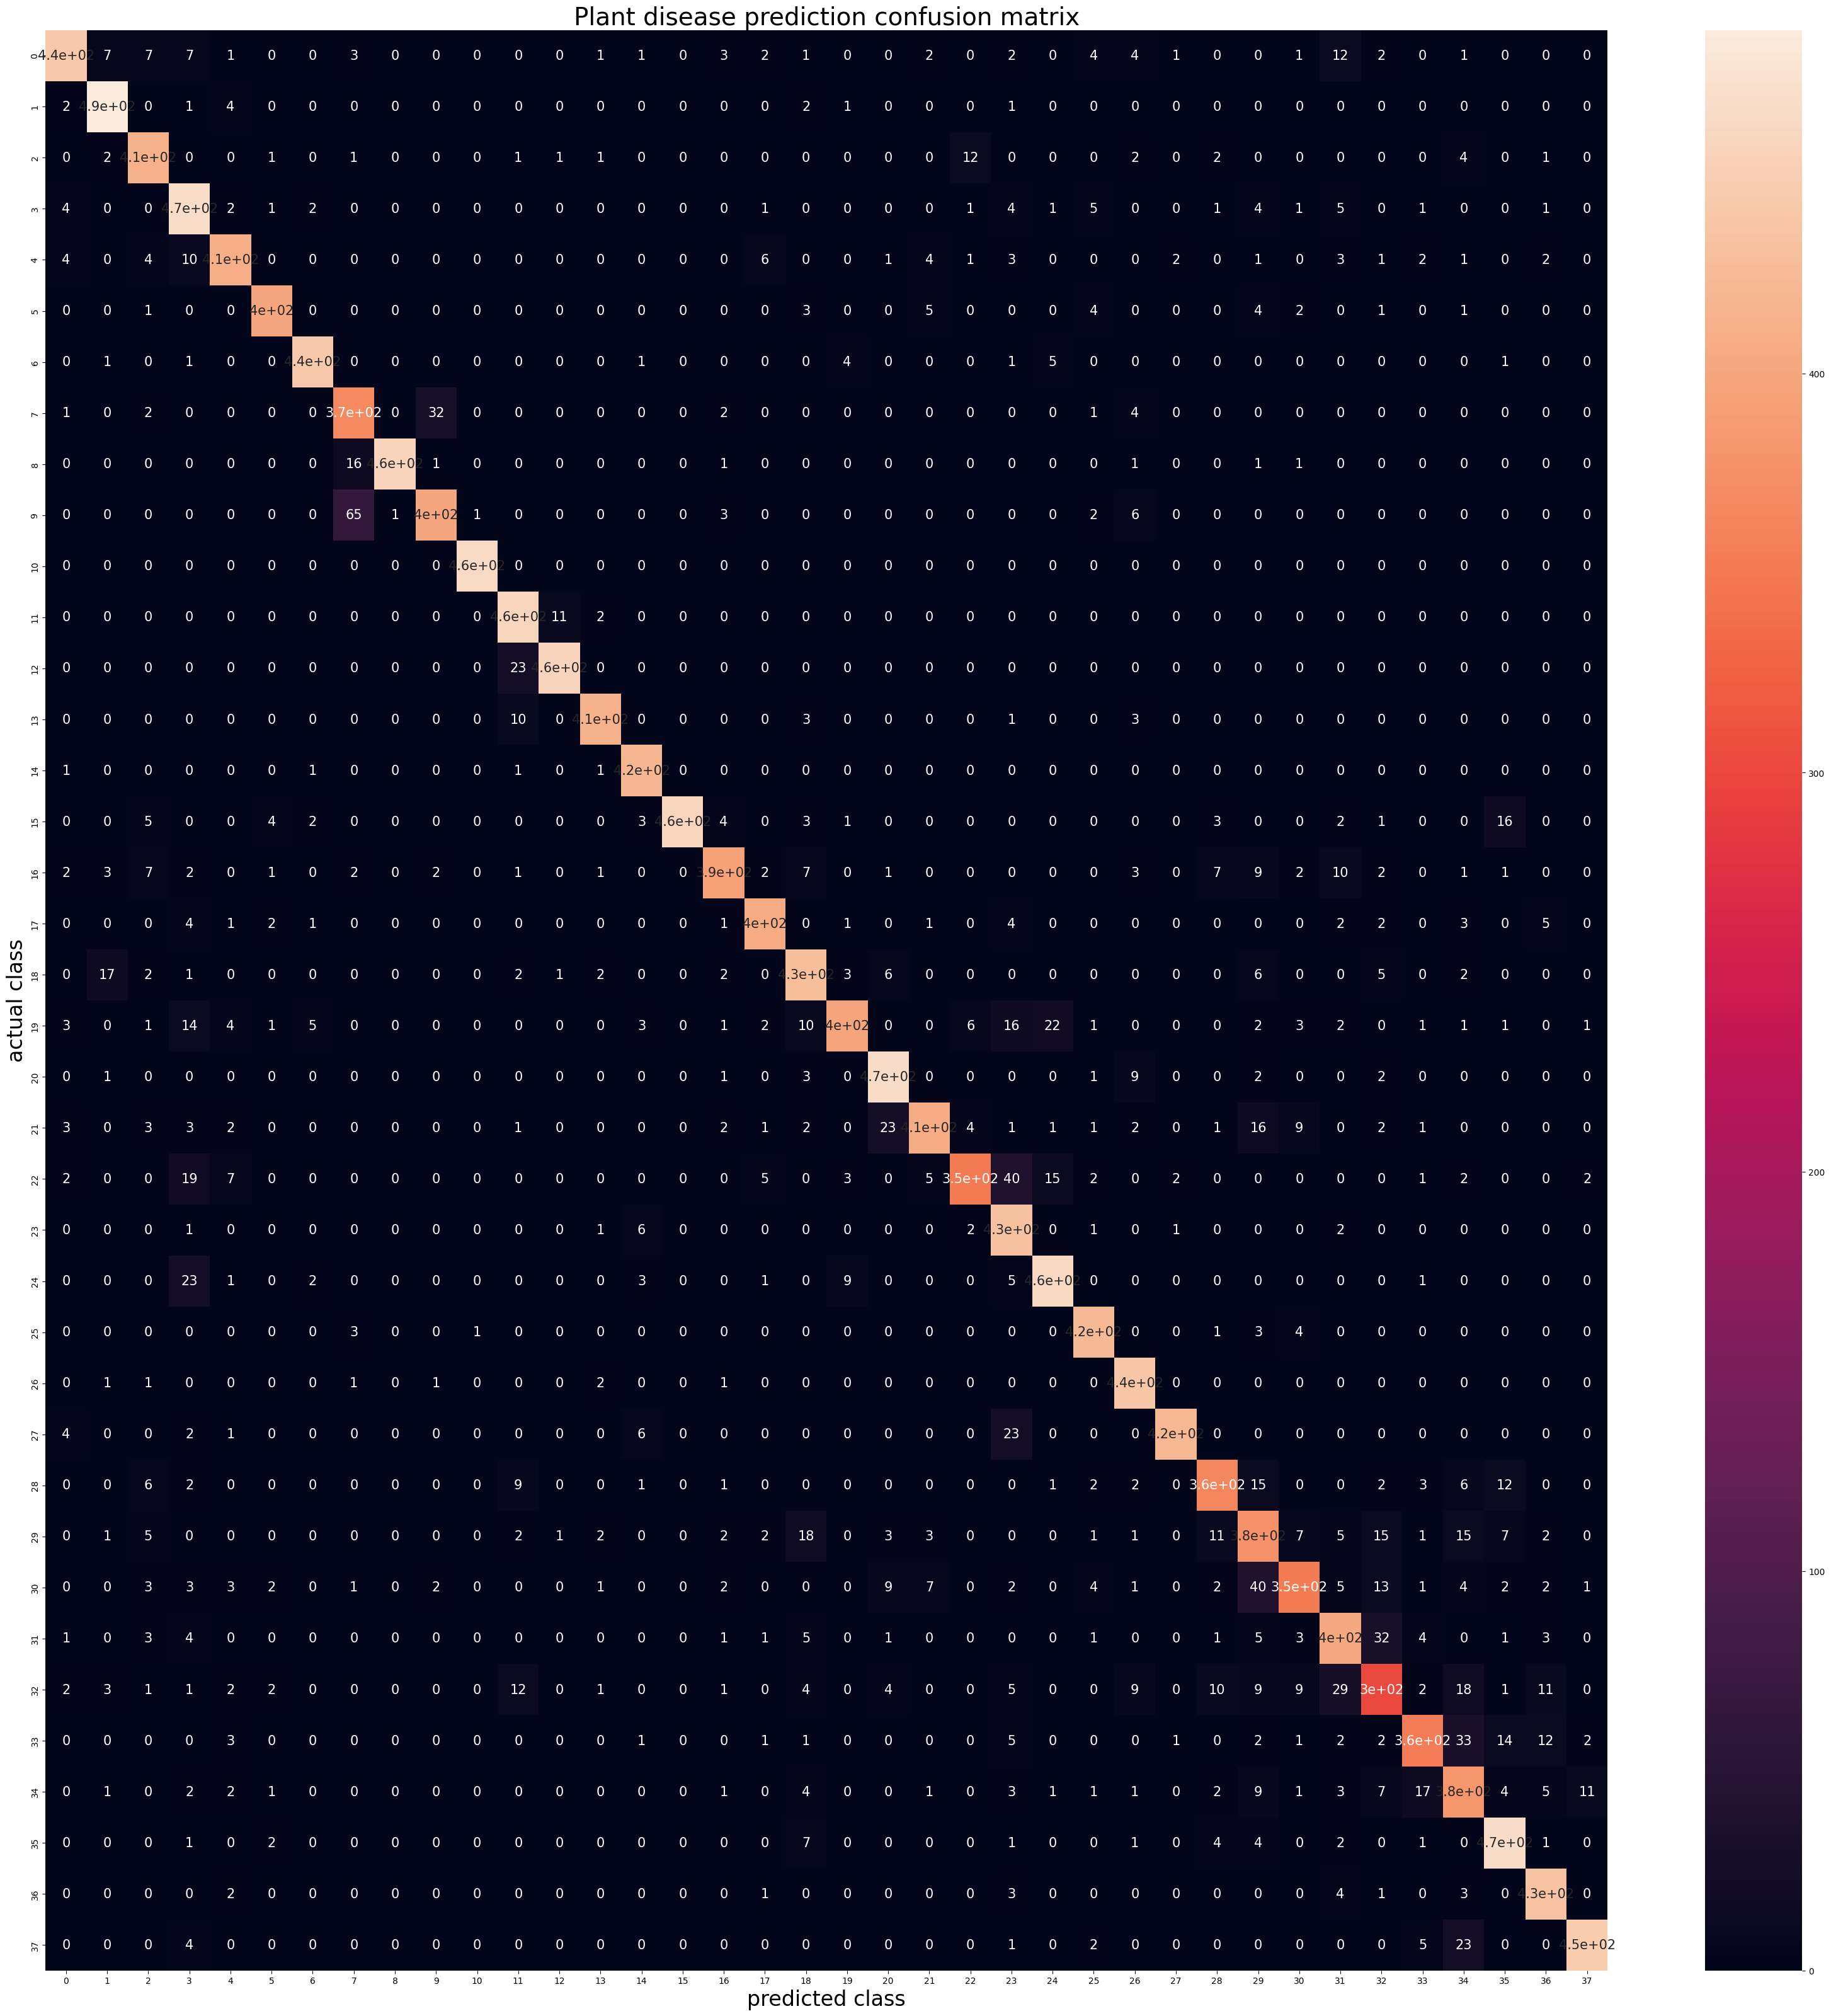

In [54]:
plt.figure(figsize=(40,40))
sns.heatmap(cm, annot=True, annot_kws={'size': 15})
plt.xlabel("predicted class", fontsize=24)
plt.ylabel("actual class", fontsize=24)
plt.title("Plant disease prediction confusion matrix", fontsize=28)
plt.show()

## TESTING PLANT DISEASE

In [55]:
#importing libraries
import tensorflow as tf 
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [56]:
#LOADING MODEL
model = tf.keras.models.load_model('/kaggle/working/trained_disease.keras')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,968,340 (205.87 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,978,894 (137.25 MB)

## Visualizing single image of test set

In [57]:
import cv2

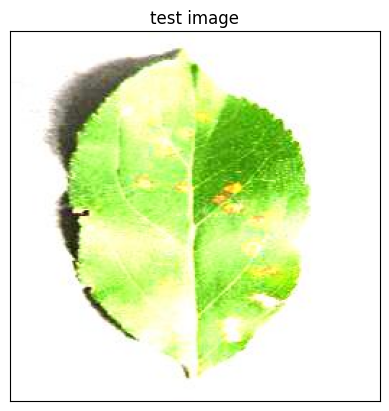

In [58]:
image_path = "/kaggle/input/plant-disease-detection/Plant_Disease_Dataset/Plant_Disease_Dataset/test/test/AppleCedarRust1.JPG"

#reading image
img = cv2.imread(image_path)            #by default, BGR format 
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #conver BGR image to RGB

#displaying image
plt.imshow(img)
plt.title("test image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing model

In [59]:
import tensorflow as tf
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr= tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])   #convert single image to a batch
print(input_arr.shape)

(1, 128, 128, 3)


In [ ]:
prediction = model.predict(input_arr)
prediction, prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step


(array([[4.18874832e-18, 3.34775908e-13, 1.00000000e+00, 6.94782213e-20,
         8.22889120e-14, 2.33666902e-26, 7.10458578e-20, 7.62041153e-15,
         5.20303774e-22, 1.88469236e-18, 6.54606977e-29, 1.69964112e-10,
         1.58612395e-13, 6.09536979e-15, 2.88267779e-15, 1.11116555e-19,
         3.79631465e-10, 3.58107580e-19, 5.71129805e-16, 1.97618825e-18,
         2.21932295e-13, 3.45750485e-15, 2.27440638e-17, 4.52291546e-12,
         1.56275983e-22, 3.92535806e-24, 2.31862654e-11, 7.80901614e-22,
         2.25495386e-11, 2.96230148e-18, 1.09563156e-16, 2.00326208e-18,
         4.39483831e-11, 9.42394795e-18, 5.33412942e-15, 6.10672109e-17,
         2.54523293e-17, 1.82486796e-18]], dtype=float32),
 (1, 38))

In [61]:
result_index = np.argmax(prediction)
result_index

2

In [62]:
class_name = ['Apple_Apple_scab',
 'Apple_Black_rot',
 'Apple_Cedar_apple_rust',
 'Apple_healthy',
 'Blueberry_healthy',
 'Cherry_including_sour_Powdery_mildew',
 'Cherry_including_sour_healthy',
 'Corn_maize_Cercospora_leaf_spot_Gray_leaf_spot',
 'Corn_maize_Common_rust_',
 'Corn_maize_Northern_Leaf_Blight',
 'Corn_maize_healthy',
 'Grape_Black_rot',
 'Grape_Esca_Black_Measles',
 'Grape_Leaf_blight_Isariopsis_Leaf_Spot',
 'Grape_healthy',
 'Orange_Haunglongbing_Citrus_greening',
 'Peach_Bacterial_spot',
 'Peach_healthy',
 'Pepper_bell_Bacterial_spot',
 'Pepper_bell_healthy',
 'Potato_Early_blight',
 'Potato_Late_blight',
 'Potato_healthy',
 'Raspberry_healthy',
 'Soybean_healthy',
 'Squash_Powdery_mildew',
 'Strawberry_Leaf_scorch',
 'Strawberry_healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two-spotted_spider_mite',
 'Tomato_Target_Spot',
 'Tomato_Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato_Tomato_mosaic_virus',
 'Tomato_healthy']
 

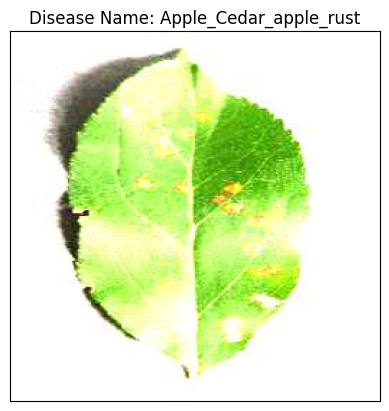

'Apple_Cedar_apple_rust'

In [63]:
#displaying result of model prediction 
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()
model_prediction